# FNO Model 3 (Omega + 3 channels, 4 total)\n\nTrue 3D grid learning: low-res train/val + high-res test (zero-shot SR).


In [1]:
# =========================
# Imports and experiment configuration (3D grid training)
# =========================
import glob
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

# Central config: edit here only.
CFG = {
    # Random seed for reproducibility across numpy/torch/data split steps.
    'seed': 42,
    # Switch for quick preliminary runs before full-scale training.
    'fast_sanity_mode': False,

    # Low-resolution train/val directories (3D projected data).
    'trainval_dirs': [
        '/media/dysco/New Volume/Neeraj/neuralop/data/train/pair_1_fno_16',
        '/media/dysco/New Volume/Neeraj/neuralop/data/train/pair_2_fno_16',
        '/media/dysco/New Volume/Neeraj/neuralop/data/train/pair_3_fno_16',
        '/media/dysco/New Volume/Neeraj/neuralop/data/train/pair_4_fno_16',
        '/media/dysco/New Volume/Neeraj/neuralop/data/train/pair_5_fno_16',
    ],

    # Optional separate test directories.
    'test_dirs': [],

    # Train/val split (forced to random 80/20 in data cell for this notebook).
    'split_mode': 'random',
    'train_frac': 0.8,

    # 3D resolution checks.
    'train_expected_res': 16,
    'test_expected_res': 32,

    # If True, training still runs even when no test dirs are provided.
    'allow_missing_test_dirs': True,

    # Optional file caps for quick sanity runs.
    'max_train_files': 256,
    'max_val_files': 64,
    'max_test_files': 64,

    # Spatial subsampling stride in dataset loader.
    'train_grid_stride': 1,
    'val_grid_stride': 1,
    'test_grid_stride': None,

    # Feature scaling controls (computed from TRAIN split only).
    'normalize_inputs': True,
    'normalize_targets': True,
    'norm_eps': 1e-6,
    'norm_max_files': 192,

    # Optimization.
    'batch_size': 2,
    'epochs': 120,
    'lr': 1e-3,
    'weight_decay': 1e-4,

    # FNO architecture.
    'n_modes': (6, 6, 6),
    'hidden_channels': 48,
    'projection_channel_ratio': 2,

    # Evaluate every N epochs.
    'eval_every': 1,

    # Variant-specific fields.
    'input_channels': 4,
    'input_key': 'input_grid_omega4',
    'file_tag': 'fno_model3_3d',
}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG['seed'])
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Variant:', CFG['input_key'], 'channels=', CFG['input_channels'])
print('Split mode (config):', CFG['split_mode'])
print('Train fraction (config):', CFG['train_frac'])
print('Fast sanity mode:', CFG['fast_sanity_mode'])
print('File caps train/val/test:', CFG['max_train_files'], CFG['max_val_files'], CFG['max_test_files'])
print('Grid stride train/val/test:', CFG['train_grid_stride'], CFG['val_grid_stride'], CFG['test_grid_stride'])
print('Normalize inputs/targets:', CFG['normalize_inputs'], CFG['normalize_targets'])



Device: cpu
Variant: input_grid_omega4 channels= 4
Split mode (config): random
Train fraction (config): 0.8
Fast sanity mode: False
File caps train/val/test: 256 64 64
Grid stride train/val/test: 1 1 None
Normalize inputs/targets: True True


In [2]:
# =========================
# Data setup (3D train/val + optional 3D test) + normalization
# =========================
cwd = Path.cwd().resolve()
if (cwd / '.git').exists():
    REPO_ROOT = cwd
elif (cwd.parent / '.git').exists():
    REPO_ROOT = cwd.parent
else:
    # Fallback for notebook servers launched outside repo root.
    REPO_ROOT = cwd

print('Detected REPO_ROOT:', REPO_ROOT)

RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Results directory:', RESULTS_DIR)

# Force this notebook to use random 80/20 train/val split.
CFG['split_mode'] = 'random'
CFG['train_frac'] = 0.8
print('[info] fno_model3 forcing split_mode=random, train_frac=0.8')


def save_fig(fig, filename, dpi=220):
    out = RESULTS_DIR / f"{CFG['file_tag']}_{filename}"
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f'[saved] {out}')


def resolve_dirs(rel_dirs, must_exist=True):
    dirs = []
    for d in rel_dirs:
        p = (REPO_ROOT / d).resolve()
        if p.is_dir():
            dirs.append(p)
        elif must_exist:
            raise FileNotFoundError(f'Missing directory: {p}')
        else:
            print(f'[warn] test directory missing, skipping: {p}')
    return dirs


TRAINVAL_DIRS = resolve_dirs(CFG['trainval_dirs'], must_exist=True)
TEST_DIRS = resolve_dirs(CFG['test_dirs'], must_exist=not CFG['allow_missing_test_dirs'])


def frame_num_from_name(path_str):
    parts = Path(path_str).stem.split('_')
    for tok in parts:
        if tok.isdigit():
            return int(tok)
    return 10**12


def list_frame_files(sim_dir, expect_gridded=True):
    grid_files = sorted(
        glob.glob(str(sim_dir / 'frame_*_grid.npz')),
        key=frame_num_from_name,
    )
    if grid_files:
        return grid_files

    raw_files = sorted(
        glob.glob(str(sim_dir / 'frame_*.npz')),
        key=frame_num_from_name,
    )

    if raw_files and expect_gridded:
        sample = np.load(raw_files[0])
        raise RuntimeError(
            f"Directory {sim_dir} has raw frame_*.npz ({len(raw_files)} files) but no frame_*_grid.npz. "
            f"Sample keys: {list(sample.files)}. "
            "This notebook expects gridded data with U_grid/input_grid_* keys. "
            "Run dataset_gen/autodomain_particle_grid.py and point CFG train/test dirs to pair_*_fno* folders."
        )

    return raw_files


def gridded_file_is_valid(file_path, input_key, expected_channels):
    try:
        d = np.load(file_path)
    except Exception as exc:
        return False, f'load_error: {exc}'

    if input_key not in d:
        return False, f"missing_input_key:{input_key}"
    if 'U_grid' not in d:
        return False, 'missing_output_key:U_grid'

    x = np.asarray(d[input_key], dtype=np.float32)
    y = np.asarray(d['U_grid'], dtype=np.float32)

    if x.ndim != 4 or y.ndim != 4:
        return False, f'bad_rank:x{tuple(x.shape)}_y{tuple(y.shape)}'
    if x.shape[0] != expected_channels:
        return False, f'bad_input_channels:{x.shape[0]}!=exp{expected_channels}'
    if y.shape[0] != 3:
        return False, f'bad_output_channels:{y.shape[0]}'
    if x.shape[-3:] != y.shape[-3:]:
        return False, f'res_mismatch:x{tuple(x.shape[-3:])}_y{tuple(y.shape[-3:])}'

    if not np.isfinite(x).all():
        return False, 'non_finite_input'
    if not np.isfinite(y).all():
        return False, 'non_finite_output'

    return True, 'ok'


def filter_valid_gridded_files(files, input_key, expected_channels, label, max_report=5):
    valid = []
    dropped = []
    for fp in files:
        ok, reason = gridded_file_is_valid(fp, input_key=input_key, expected_channels=expected_channels)
        if ok:
            valid.append(fp)
        else:
            dropped.append((fp, reason))

    if dropped:
        print(f"[warn] {label}: dropped {len(dropped)} invalid files")
        for fp, reason in dropped[:max_report]:
            print(f"    - {Path(fp).name}: {reason}")
        if len(dropped) > max_report:
            print(f"    ... and {len(dropped) - max_report} more")

    return valid


def split_train_val(files, train_frac=0.8, mode='random', seed=42):
    files = list(files)
    n = len(files)

    if n == 0:
        return [], []
    if n == 1:
        return files, []

    # Force random split for this notebook, even if mode is changed upstream.
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    files = [files[i] for i in idx]

    n_train = max(1, int(train_frac * n))
    n_train = min(n_train, n - 1)
    return files[:n_train], files[n_train:]


TRAIN_FILES, VAL_FILES = [], []
for i, d in enumerate(TRAINVAL_DIRS):
    files = list_frame_files(d, expect_gridded=True)
    if len(files) == 0:
        print(f"[warn] no frame files found in train/val dir: {d}")
        continue

    files = filter_valid_gridded_files(
        files,
        input_key=CFG['input_key'],
        expected_channels=CFG['input_channels'],
        label=f"{d.name} (train/val)",
    )
    if len(files) == 0:
        print(f"[warn] no valid gridded files remain in train/val dir: {d}")
        continue

    tr, va = split_train_val(
        files,
        train_frac=CFG['train_frac'],
        mode=CFG['split_mode'],
        seed=CFG['seed'] + i,
    )
    TRAIN_FILES.extend(tr)
    VAL_FILES.extend(va)
    print(f"[info] {d.name}: valid_total={len(files)}, train={len(tr)}, val={len(va)}")

if len(TRAIN_FILES) == 0:
    raise RuntimeError(
        "No training files found after directory scan/filtering. "
        "Check CFG['trainval_dirs'] and ensure valid frame_*_grid.npz files exist."
    )
if len(VAL_FILES) == 0:
    raise RuntimeError(
        "Validation split is empty after filtering. Add more frames or reduce train_frac."
    )

TEST_FILES = []
for d in TEST_DIRS:
    files = list_frame_files(d, expect_gridded=True)
    if len(files) == 0:
        print(f"[warn] no frame files found in test dir: {d}")
        continue

    files = filter_valid_gridded_files(
        files,
        input_key=CFG['input_key'],
        expected_channels=CFG['input_channels'],
        label=f"{d.name} (test)",
    )
    TEST_FILES.extend(files)

HAS_TEST = len(TEST_FILES) > 0
if not HAS_TEST:
    print("[warn] No valid test files found. Test metrics/plots will be skipped.")

if CFG.get('max_train_files') and len(TRAIN_FILES) > CFG['max_train_files']:
    rng = np.random.default_rng(CFG['seed'] + 1101)
    idx = rng.choice(len(TRAIN_FILES), size=CFG['max_train_files'], replace=False)
    TRAIN_FILES = [TRAIN_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] train file cap active: using {len(TRAIN_FILES)} files")

if CFG.get('max_val_files') and len(VAL_FILES) > CFG['max_val_files']:
    rng = np.random.default_rng(CFG['seed'] + 1201)
    idx = rng.choice(len(VAL_FILES), size=CFG['max_val_files'], replace=False)
    VAL_FILES = [VAL_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] val file cap active: using {len(VAL_FILES)} files")

if HAS_TEST and CFG.get('max_test_files') and len(TEST_FILES) > CFG['max_test_files']:
    rng = np.random.default_rng(CFG['seed'] + 1301)
    idx = rng.choice(len(TEST_FILES), size=CFG['max_test_files'], replace=False)
    TEST_FILES = [TEST_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] test file cap active: using {len(TEST_FILES)} files")

print(f"Train files: {len(TRAIN_FILES)} | Val files: {len(VAL_FILES)} | Test files: {len(TEST_FILES)}")


def preview_index_map(files, label, max_items=8):
    print(f"[{label}] index preview (first {min(len(files), max_items)} entries)")
    for i, fp in enumerate(files[:max_items]):
        print(f"  idx={i:03d} frame={frame_num_from_name(fp)} file={Path(fp).name}")


preview_index_map(TRAIN_FILES, 'TRAIN')
preview_index_map(VAL_FILES, 'VAL')
if HAS_TEST:
    preview_index_map(TEST_FILES, 'TEST')


def load_x(data):
    key = CFG['input_key']
    if key not in data:
        raise KeyError(f"Missing key '{key}'. Available: {data.files}")
    x = np.asarray(data[key], dtype=np.float32)
    return x


def infer_expected_res(file_path):
    d = np.load(file_path)
    x = load_x(d)
    if x.ndim >= 4:
        return int(x.shape[-1])
    return None

def resolve_expected_res(files, expected_res, label):
    if len(files) == 0:
        return expected_res
    actual = infer_expected_res(files[0])
    if expected_res in (None, "auto"):
        print(f"[info] {label} expected_res auto-set to {actual}")
        return actual
    if actual is not None and actual != expected_res:
        print(f"[warn] {label} expected_res={expected_res} but data shows {actual}; using data value")
        return actual
    return expected_res


def assert_shapes(files, expected_channels, expected_res=None, label='set'):
    if len(files) == 0:
        return

    bad = []
    for f in files:
        d = np.load(f)
        x = load_x(d)
        y = np.asarray(d['U_grid'], dtype=np.float32)

        ok_channels = (x.shape[0] == expected_channels and y.shape[0] == 3)
        ok_rank = (x.ndim == 4 and y.ndim == 4)

        ok_res = True
        if expected_res is not None:
            ok_res = (
                x.shape[-3:] == (expected_res, expected_res, expected_res)
                and y.shape[-3:] == (expected_res, expected_res, expected_res)
            )

        if not (ok_channels and ok_rank and ok_res):
            bad.append((f, tuple(x.shape), tuple(y.shape)))
            if len(bad) >= 5:
                break

    if bad:
        msg = '\n'.join([f"{fp} -> x:{xs}, y:{ys}" for fp, xs, ys in bad])
        raise RuntimeError(f"{label} shape check failed. Examples:\n{msg}")


def assert_no_overlap(a, b):
    inter = set(a).intersection(set(b))
    if inter:
        raise RuntimeError(f"Train/val leakage detected with {len(inter)} overlapping files")


assert_no_overlap(TRAIN_FILES, VAL_FILES)
train_res = resolve_expected_res(TRAIN_FILES, CFG["train_expected_res"], "train")
val_res = resolve_expected_res(VAL_FILES, CFG["train_expected_res"], "val")
if HAS_TEST:
    test_res = resolve_expected_res(TEST_FILES, CFG["test_expected_res"], "test")
else:
    test_res = CFG["test_expected_res"]

CFG["train_expected_res"] = train_res
CFG["test_expected_res"] = test_res

assert_shapes(TRAIN_FILES, expected_channels=CFG["input_channels"], expected_res=train_res, label="train")
assert_shapes(VAL_FILES, expected_channels=CFG["input_channels"], expected_res=val_res, label="val")
if HAS_TEST:
    assert_shapes(TEST_FILES, expected_channels=CFG["input_channels"], expected_res=test_res, label="test")


try:
    NORMALIZER
except NameError:
    NORMALIZER = None
    print('[warn] NORMALIZER undefined; normalization disabled for this run')

class GridDataset(Dataset):
    def __init__(self, files, grid_stride=1, normalizer=None):
        self.files = list(files)
        self.grid_stride = 1 if grid_stride is None else int(grid_stride)
        self.normalizer = normalizer

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        x = torch.tensor(load_x(d), dtype=torch.float32)
        y = torch.tensor(np.asarray(d['U_grid'], dtype=np.float32), dtype=torch.float32)

        s = self.grid_stride
        if s > 1:
            x = x[:, ::s, ::s, ::s]
            y = y[:, ::s, ::s, ::s]

        if self.normalizer is not None:
            if CFG['normalize_inputs']:
                x = self.normalizer.normalize_x(x)
            if CFG['normalize_targets']:
                y = self.normalizer.normalize_y(y)

        return x, y


TRAIN_DS = GridDataset(TRAIN_FILES, grid_stride=CFG['train_grid_stride'], normalizer=NORMALIZER)
VAL_DS = GridDataset(VAL_FILES, grid_stride=CFG['val_grid_stride'], normalizer=NORMALIZER)
TEST_DS = GridDataset(TEST_FILES, grid_stride=CFG['test_grid_stride'], normalizer=NORMALIZER) if HAS_TEST else None

drop_last = len(TRAIN_DS) >= CFG['batch_size']
TRAIN_LOADER = DataLoader(TRAIN_DS, batch_size=CFG['batch_size'], shuffle=True, drop_last=drop_last)
VAL_LOADER = DataLoader(VAL_DS, batch_size=CFG['batch_size'], shuffle=False)
TEST_LOADER = DataLoader(TEST_DS, batch_size=CFG['batch_size'], shuffle=False) if HAS_TEST else None

xtr, ytr = TRAIN_DS[0]
xva, yva = VAL_DS[0]
print('Train sample shape:', tuple(xtr.shape), tuple(ytr.shape))
print('Val sample shape  :', tuple(xva.shape), tuple(yva.shape))
if HAS_TEST:
    xte, yte = TEST_DS[0]
    print('Test sample shape :', tuple(xte.shape), tuple(yte.shape))



Detected REPO_ROOT: /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO
Results directory: /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results
[info] fno_model3 forcing split_mode=random, train_frac=0.8
[warn] pair_1_fno_16 (train/val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_1_fno_16: valid_total=199, train=159, val=40
[warn] pair_2_fno_16 (train/val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_2_fno_16: valid_total=199, train=159, val=40
[warn] pair_3_fno_16 (train/val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_3_fno_16: valid_total=359, train=287, val=72
[warn] pair_4_fno_16 (train/val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_4_fno_16: valid_total=359, train=287, val=72
[warn] pair_5_fno_16 (train/val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_5_fno_16: valid_total=179, train=143, val

In [3]:
# =========================
# 3D FNO model + optimizer + metrics
# =========================
def build_model(cfg):
    return FNO(
        n_modes=cfg['n_modes'],
        in_channels=cfg['input_channels'],
        out_channels=3,
        hidden_channels=cfg['hidden_channels'],
        projection_channel_ratio=cfg['projection_channel_ratio'],
    ).to(DEVICE)


MODEL = build_model(CFG)

total_params = count_model_params(MODEL)
trainable_params = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print('Total params:', total_params)
print('Trainable params:', trainable_params)

OPT = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
SCH = torch.optim.lr_scheduler.CosineAnnealingLR(OPT, T_max=CFG['epochs'])
LOSS_FN = LpLoss(d=3, p=2)


def predict(model, x):
    return model(x)


def to_physical_y(t):
    # Convert model-space target/prediction tensors back to physical units for metrics/plots.
    try:
        return denormalize_target_tensor(t)
    except NameError:
        return t
def batch_metrics(pred, target):
    pred_phys = to_physical_y(pred)
    target_phys = to_physical_y(target)

    diff = pred_phys - target_phys
    mse = torch.mean(diff ** 2, dim=(1, 2, 3, 4))
    mae = torch.mean(torch.abs(diff), dim=(1, 2, 3, 4))
    rmse = torch.sqrt(mse)

    diff_flat = diff.reshape(diff.shape[0], -1)
    tgt_flat = target_phys.reshape(target_phys.shape[0], -1)
    rel_l2 = torch.linalg.norm(diff_flat, dim=1) / torch.linalg.norm(tgt_flat, dim=1).clamp_min(1e-12)

    return {
        'mse': mse.mean().item(),
        'mae': mae.mean().item(),
        'rmse': rmse.mean().item(),
        'rel_l2': rel_l2.mean().item(),
        'rel_vec': rel_l2.detach().cpu().numpy(),
    }


@torch.no_grad()
def evaluate(model, loader, collect=False):
    if loader is None:
        return None

    model.eval()
    acc = {'mse': 0.0, 'mae': 0.0, 'rmse': 0.0, 'rel_l2': 0.0}
    rels = []
    nb = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = predict(model, x)
        m = batch_metrics(pred, y)
        for k in acc:
            acc[k] += m[k]
        if collect:
            rels.extend(m['rel_vec'].tolist())
        nb += 1

    for k in acc:
        acc[k] /= max(nb, 1)
    if collect:
        acc['rel_per_sample'] = np.asarray(rels, dtype=np.float32)
    return acc



Total params: 2683731
Trainable params: 1356627


In [4]:
# =========================
# Training loop (3D low-res train/val + optional high-res test)
# =========================
HIST = {
    'epoch': [],
    # LpLoss value in normalized target space (optimization objective).
    'train_lp': [],
    # Relative L2 in physical units for easier interpretation.
    'train_rel_l2': [],
    'val_rel_l2': [],
    'val_rmse': [],
    'test_rel_l2': [],
    'test_rmse': [],
    'lr': [],
}

best_val = float('inf')
CKPT_PATH = RESULTS_DIR / f"{CFG['file_tag']}_best_model.pt"

for epoch in range(1, CFG['epochs'] + 1):
    MODEL.train()
    run_loss = 0.0
    run_rel = 0.0
    nb = 0

    for x, y in TRAIN_LOADER:
        x, y = x.to(DEVICE), y.to(DEVICE)
        OPT.zero_grad(set_to_none=True)
        pred = predict(MODEL, x)

        # Optimization loss in normalized space.
        loss = LOSS_FN(pred, y)
        loss.backward()
        OPT.step()

        run_loss += loss.item()
        run_rel += batch_metrics(pred.detach(), y)['rel_l2']
        nb += 1

    SCH.step()
    train_lp = run_loss / max(nb, 1)
    train_rel = run_rel / max(nb, 1)

    if epoch % CFG['eval_every'] == 0:
        val_m = evaluate(MODEL, VAL_LOADER)
        test_m = evaluate(MODEL, TEST_LOADER) if HAS_TEST else None

        HIST['epoch'].append(epoch)
        HIST['train_lp'].append(train_lp)
        HIST['train_rel_l2'].append(train_rel)
        HIST['val_rel_l2'].append(val_m['rel_l2'])
        HIST['val_rmse'].append(val_m['rmse'])
        HIST['test_rel_l2'].append(test_m['rel_l2'] if test_m is not None else np.nan)
        HIST['test_rmse'].append(test_m['rmse'] if test_m is not None else np.nan)
        HIST['lr'].append(OPT.param_groups[0]['lr'])

        if val_m['rel_l2'] < best_val:
            best_val = val_m['rel_l2']
            torch.save(
                {
                    'model_state_dict': MODEL.state_dict(),
                    'config': dict(CFG),
                    'best_val_rel_l2': best_val,
                },
                CKPT_PATH,
            )

        msg = (
            f"[{epoch:03d}] train_lp(norm)={train_lp:.4e} "
            f"train_rel_l2(phys)={train_rel:.4e} "
            f"val_rel_l2(phys)={val_m['rel_l2']:.4e} val_rmse(phys)={val_m['rmse']:.4e} "
            f"lr={HIST['lr'][-1]:.2e}"
        )
        if test_m is not None:
            msg += f" test_rel_l2(phys)={test_m['rel_l2']:.4e} test_rmse(phys)={test_m['rmse']:.4e}"
        print(msg)

print(f"Best val rel-L2: {best_val:.4e}")
print(f"Checkpoint: {CKPT_PATH}")


[001] train_lp(norm)=6.0805e+00 train_rel_l2(phys)=1.0055e+00 val_rel_l2(phys)=9.9021e-01 val_rmse(phys)=2.3676e-01 lr=1.00e-03
[002] train_lp(norm)=5.8506e+00 train_rel_l2(phys)=9.7263e-01 val_rel_l2(phys)=9.6837e-01 val_rmse(phys)=2.2518e-01 lr=9.99e-04
[003] train_lp(norm)=5.4615e+00 train_rel_l2(phys)=9.0430e-01 val_rel_l2(phys)=9.0651e-01 val_rmse(phys)=1.9293e-01 lr=9.98e-04
[004] train_lp(norm)=5.1422e+00 train_rel_l2(phys)=8.4937e-01 val_rel_l2(phys)=8.6227e-01 val_rmse(phys)=1.7370e-01 lr=9.97e-04
[005] train_lp(norm)=4.8648e+00 train_rel_l2(phys)=8.0084e-01 val_rel_l2(phys)=8.3876e-01 val_rmse(phys)=1.6266e-01 lr=9.96e-04
[006] train_lp(norm)=4.6984e+00 train_rel_l2(phys)=7.7376e-01 val_rel_l2(phys)=8.2023e-01 val_rmse(phys)=1.5819e-01 lr=9.94e-04
[007] train_lp(norm)=4.6097e+00 train_rel_l2(phys)=7.5131e-01 val_rel_l2(phys)=8.0038e-01 val_rmse(phys)=1.5306e-01 lr=9.92e-04
[008] train_lp(norm)=4.4906e+00 train_rel_l2(phys)=7.3938e-01 val_rel_l2(phys)=7.7574e-01 val_rmse(phys)

In [5]:
# =========================
# Post-training test snippet (load best checkpoint and test)
# =========================
if not HAS_TEST:
    print("[skip] No test split available. Fill CFG['test_dirs'] and rerun.")
else:
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()

    test_m = evaluate(MODEL, TEST_LOADER, collect=True)
    print('Loaded checkpoint:', CKPT_PATH)
    if isinstance(ckpt, dict):
        print('Checkpoint best val rel-L2:', ckpt.get('best_val_rel_l2', 'n/a'))
    else:
        print('Checkpoint best val rel-L2: n/a (state_dict only)')
    print(
        f"Post-train TEST metrics -> rel-L2={test_m['rel_l2']:.4e}, "
        f"RMSE={test_m['rmse']:.4e}, MAE={test_m['mae']:.4e}, MSE={test_m['mse']:.4e}"
    )


[skip] No test split available. Fill CFG['test_dirs'] and rerun.


[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/fno_model3_3d_params_by_module.png


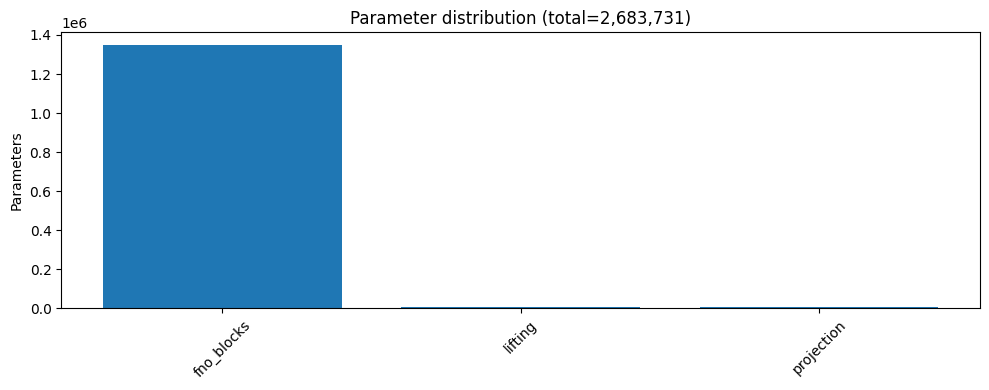

[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/fno_model3_3d_convergence_zero_shot_sr.png


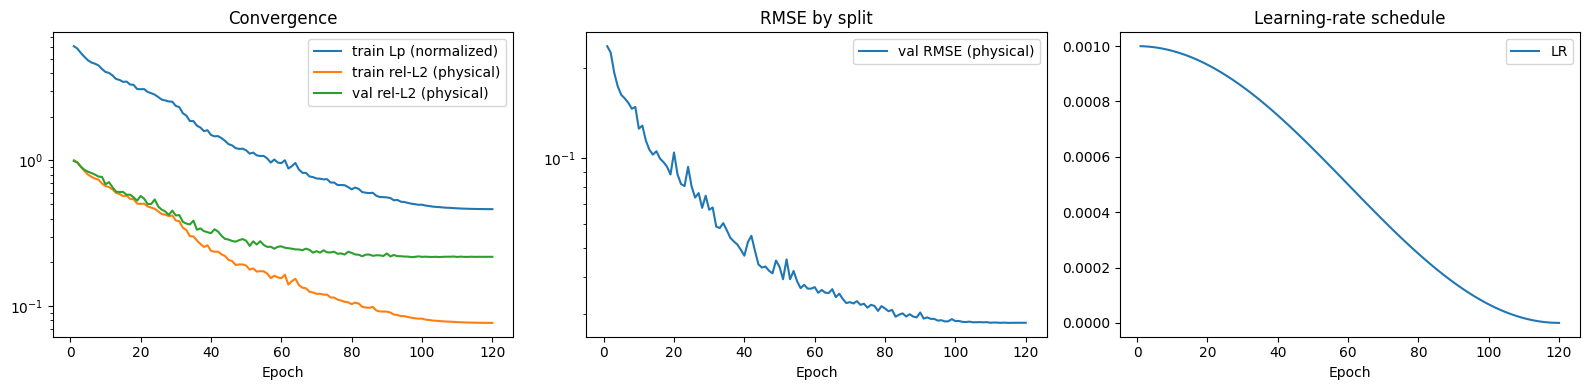

[TRAIN] representative sample indices from first 256 -> best=65 (rel=1.437e-02), median=99 (rel=7.228e-02), worst=126 (rel=4.148e-01)


In [ ]:
# =========================
# Core plots (3D): convergence + y-plane diagnostics
# =========================
def speed_from_velocity(u_chw):
    # Convert velocity channels [Ux, Uy, Uz] into scalar speed [Nx, Ny, Nz].
    return torch.linalg.norm(u_chw, dim=0).cpu().numpy()


def y_slice_indices(ny):
    # Requested planes: end, quarter, and mid along y-axis.
    return {
        'end': max(0, ny - 1),
        'quarter': max(0, ny // 4),
        'mid': max(0, ny // 2),
    }


def xz_views_at_y(vol):
    idx = y_slice_indices(vol.shape[1])
    return {
        'end': vol[:, idx['end'], :],
        'quarter': vol[:, idx['quarter'], :],
        'mid': vol[:, idx['mid'], :],
    }, idx


@torch.no_grad()
def sample_rel_l2(model, x_norm, y_norm):
    p_norm = predict(model, x_norm.unsqueeze(0).to(DEVICE))[0].cpu()
    p_phys = to_physical_y(p_norm)
    y_phys = to_physical_y(y_norm)
    rel = (
        torch.linalg.norm((p_phys - y_phys).reshape(-1))
        / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
    ).item()
    return p_norm, rel


def representative_indices(model, ds, split_name):
    if len(ds) == 0:
        return {'best': None, 'median': None, 'worst': None}

    max_items = min(len(ds), 24 if CFG['fast_sanity_mode'] else len(ds))
    rels = []
    model.eval()
    for i in range(max_items):
        x_norm, y_norm = ds[i]
        _, rel = sample_rel_l2(model, x_norm, y_norm)
        rels.append((i, rel))

    rels_sorted = sorted(rels, key=lambda t: t[1])
    best_i = rels_sorted[0][0]
    med_i = rels_sorted[len(rels_sorted) // 2][0]
    worst_i = rels_sorted[-1][0]

    print(
        f"[{split_name}] representative sample indices from first {max_items} -> "
        f"best={best_i} (rel={rels_sorted[0][1]:.3e}), "
        f"median={med_i} (rel={rels_sorted[len(rels_sorted)//2][1]:.3e}), "
        f"worst={worst_i} (rel={rels_sorted[-1][1]:.3e})"
    )
    return {'best': best_i, 'median': med_i, 'worst': worst_i}


def plot_volume_diagnostics(ds, files, split_name, sample_idx, save_tag):
    if sample_idx is None:
        print(f"[skip] {split_name}: no sample index")
        return

    x_norm, y_norm = ds[sample_idx]
    with torch.no_grad():
        p_norm = predict(MODEL, x_norm.unsqueeze(0).to(DEVICE))[0].cpu()

    y_phys = to_physical_y(y_norm)
    p_phys = to_physical_y(p_norm)

    true_speed = speed_from_velocity(y_phys)
    pred_speed = speed_from_velocity(p_phys)
    err_speed = np.abs(pred_speed - true_speed)

    rel = (
        torch.linalg.norm((p_phys - y_phys).reshape(-1))
        / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
    ).item()

    true_views, y_idx = xz_views_at_y(true_speed)
    pred_views, _ = xz_views_at_y(pred_speed)
    err_views, _ = xz_views_at_y(err_speed)

    frame = frame_num_from_name(files[sample_idx]) if sample_idx < len(files) else -1
    fname = Path(files[sample_idx]).name if sample_idx < len(files) else 'unknown'
    print(
        f"[{split_name}] sample_idx={sample_idx}, frame={frame}, file={fname}, "
        f"y-slices(end,1/4,mid)=({y_idx['end']},{y_idx['quarter']},{y_idx['mid']}), rel-L2={rel:.3e}"
    )

    fig, axs = plt.subplots(3, 3, figsize=(12, 10))
    cols = ['end', 'quarter', 'mid']
    col_titles = {
        'end': f"XZ @ y=end ({y_idx['end']})",
        'quarter': f"XZ @ y=1/4 ({y_idx['quarter']})",
        'mid': f"XZ @ y=mid ({y_idx['mid']})",
    }

    vmin = min(v.min() for v in true_views.values())
    vmax = max(v.max() for v in true_views.values())

    for j, key in enumerate(cols):
        im0 = axs[0, j].imshow(true_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
        axs[0, j].set_title(f"True {col_titles[key]}")
        axs[0, j].axis('off')
        plt.colorbar(im0, ax=axs[0, j], fraction=0.046, pad=0.03)

        im1 = axs[1, j].imshow(pred_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
        axs[1, j].set_title(f"Pred {col_titles[key]}")
        axs[1, j].axis('off')
        plt.colorbar(im1, ax=axs[1, j], fraction=0.046, pad=0.03)

        im2 = axs[2, j].imshow(err_views[key], cmap='magma')
        axs[2, j].set_title(f"|Error| {col_titles[key]}")
        axs[2, j].axis('off')
        plt.colorbar(im2, ax=axs[2, j], fraction=0.046, pad=0.03)

    fig.suptitle(f"{split_name}: y-plane diagnostics | idx={sample_idx}, frame={frame}, rel-L2={rel:.3e}", fontsize=12)
    fig.tight_layout()
    save_fig(fig, f"qualitative_{save_tag}_y_plane_slices.png")
    plt.show()


# Parameter distribution.
module_param_counts = defaultdict(int)
for name, p in MODEL.named_parameters():
    module_param_counts[name.split('.')[0]] += p.numel()

mods = list(module_param_counts.keys())
vals = [module_param_counts[m] for m in mods]
order = np.argsort(vals)[::-1]
mods = [mods[i] for i in order]
vals = [vals[i] for i in order]

fig_p, ax_p = plt.subplots(figsize=(10, 4))
ax_p.bar(mods, vals)
ax_p.set_title(f"Parameter distribution (total={total_params:,})")
ax_p.set_ylabel('Parameters')
ax_p.tick_params(axis='x', rotation=45)
fig_p.tight_layout()
save_fig(fig_p, 'params_by_module.png')
plt.show()

# Convergence curves.
fig_c, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(HIST['epoch'], HIST['train_lp'], label='train Lp (normalized)')
axs[0].plot(HIST['epoch'], HIST['train_rel_l2'], label='train rel-L2 (physical)')
axs[0].plot(HIST['epoch'], HIST['val_rel_l2'], label='val rel-L2 (physical)')
if HAS_TEST:
    axs[0].plot(HIST['epoch'], HIST['test_rel_l2'], label='test rel-L2 (physical)')
axs[0].set_yscale('log')
axs[0].set_xlabel('Epoch')
axs[0].set_title('Convergence')
axs[0].legend()

axs[1].plot(HIST['epoch'], HIST['val_rmse'], label='val RMSE (physical)')
if HAS_TEST:
    axs[1].plot(HIST['epoch'], HIST['test_rmse'], label='test RMSE (physical)')
axs[1].set_yscale('log')
axs[1].set_xlabel('Epoch')
axs[1].set_title('RMSE by split')
axs[1].legend()

axs[2].plot(HIST['epoch'], HIST['lr'], label='LR')
axs[2].set_xlabel('Epoch')
axs[2].set_title('Learning-rate schedule')
axs[2].legend()

fig_c.tight_layout()
save_fig(fig_c, 'convergence_zero_shot_sr.png')
plt.show()

# Representative qualitative diagnostics.
MODEL.eval()
train_rep = representative_indices(MODEL, TRAIN_DS, split_name='TRAIN')
val_rep = representative_indices(MODEL, VAL_DS, split_name='VAL')
plot_volume_diagnostics(TRAIN_DS, TRAIN_FILES, 'TRAIN', train_rep['median'], save_tag='train_median')
plot_volume_diagnostics(VAL_DS, VAL_FILES, 'VAL', val_rep['median'], save_tag='val_median')
if HAS_TEST:
    test_rep = representative_indices(MODEL, TEST_DS, split_name='TEST')
    plot_volume_diagnostics(TEST_DS, TEST_FILES, 'TEST', test_rep['median'], save_tag='test_median')



[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/fno_model3_3d_relative_error_vs_epoch.png


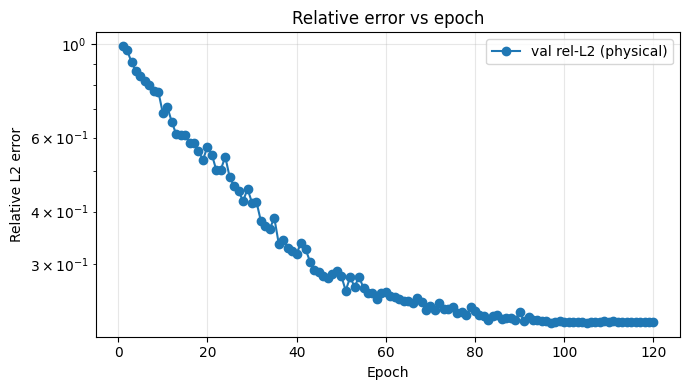

VAL (low-res) diagnostic sample idx=6, frame=15, file=frame_15_grid.npz, rel-L2=1.407e-01
[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/fno_model3_3d_error_distribution_and_parity.png


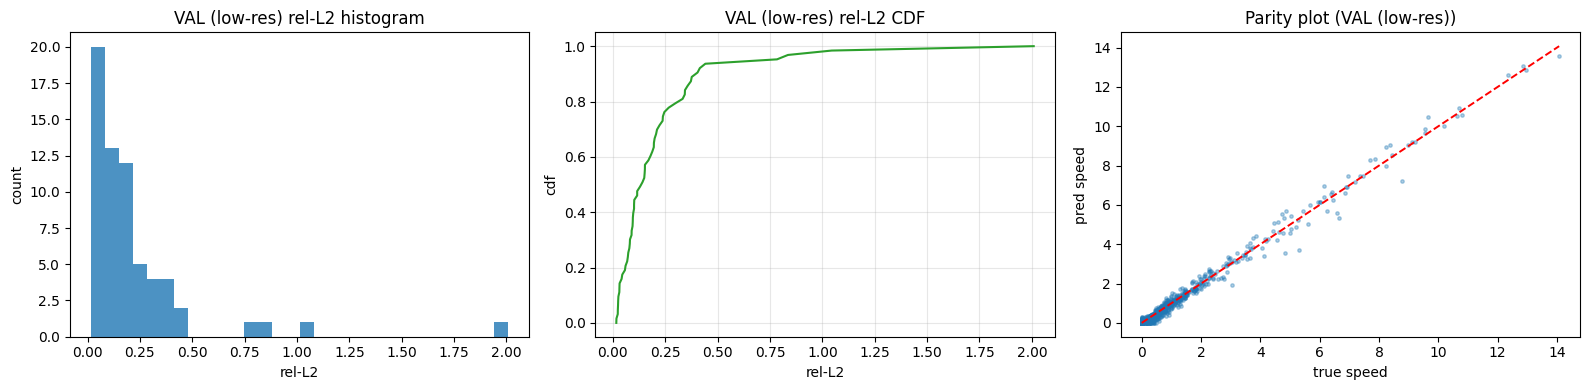

In [7]:
# =========================
# Relative error + distribution/parity diagnostics
# =========================
if len(HIST['epoch']) == 0:
    raise RuntimeError('History is empty; run training first.')

fig_r, ax_r = plt.subplots(figsize=(7, 4))
ax_r.plot(HIST['epoch'], HIST['val_rel_l2'], marker='o', label='val rel-L2 (physical)')
if HAS_TEST:
    ax_r.plot(HIST['epoch'], HIST['test_rel_l2'], marker='o', label='test rel-L2 (physical)')
ax_r.set_yscale('log')
ax_r.set_xlabel('Epoch')
ax_r.set_ylabel('Relative L2 error')
ax_r.set_title('Relative error vs epoch')
ax_r.grid(True, alpha=0.3)
ax_r.legend()
fig_r.tight_layout()
save_fig(fig_r, 'relative_error_vs_epoch.png')
plt.show()

if HAS_TEST:
    diag_loader = TEST_LOADER
    diag_ds = TEST_DS
    diag_files = TEST_FILES
    diag_label = 'TEST (high-res)'
else:
    diag_loader = VAL_LOADER
    diag_ds = VAL_DS
    diag_files = VAL_FILES
    diag_label = 'VAL (low-res)'

diag = evaluate(MODEL, diag_loader, collect=True)
rel_vals = np.asarray(diag['rel_per_sample'], dtype=np.float32)

if len(rel_vals) == 0:
    raise RuntimeError('No per-sample relative error values available for diagnostics.')

diag_idx = int(np.argsort(rel_vals)[len(rel_vals) // 2])
print(
    f"{diag_label} diagnostic sample idx={diag_idx}, frame={frame_num_from_name(diag_files[diag_idx])}, "
    f"file={Path(diag_files[diag_idx]).name}, rel-L2={rel_vals[diag_idx]:.3e}"
)

sx_norm, sy_norm = diag_ds[diag_idx]
with torch.no_grad():
    sp_norm = predict(MODEL, sx_norm.unsqueeze(0).to(DEVICE))[0].cpu()

sy_phys = to_physical_y(sy_norm)
sp_phys = to_physical_y(sp_norm)

true_speed = speed_from_velocity(sy_phys).reshape(-1)
pred_speed = speed_from_velocity(sp_phys).reshape(-1)

rng = np.random.default_rng(CFG['seed'])
if true_speed.size > 8000:
    idx = rng.choice(true_speed.size, size=8000, replace=False)
    true_speed = true_speed[idx]
    pred_speed = pred_speed[idx]

fig_d, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(rel_vals, bins=30, color='tab:blue', alpha=0.8)
axs[0].set_title(f'{diag_label} rel-L2 histogram')
axs[0].set_xlabel('rel-L2')
axs[0].set_ylabel('count')

sorted_rel = np.sort(rel_vals)
cdf = np.linspace(0, 1, len(sorted_rel), endpoint=True)
axs[1].plot(sorted_rel, cdf, color='tab:green')
axs[1].set_title(f'{diag_label} rel-L2 CDF')
axs[1].set_xlabel('rel-L2')
axs[1].set_ylabel('cdf')
axs[1].grid(True, alpha=0.3)

vmin = min(float(true_speed.min()), float(pred_speed.min()))
vmax = max(float(true_speed.max()), float(pred_speed.max()))
axs[2].scatter(true_speed, pred_speed, s=6, alpha=0.35)
axs[2].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.4)
axs[2].set_title(f'Parity plot ({diag_label})')
axs[2].set_xlabel('true speed')
axs[2].set_ylabel('pred speed')

fig_d.tight_layout()
save_fig(fig_d, 'error_distribution_and_parity.png')
plt.show()



In [8]:
# =========================
# Index-aware snapshot diagnostics using y-plane slices (XZ planes)
# =========================
try:
    normalize_input_tensor
except NameError:
    def normalize_input_tensor(x):
        return x
    print('[warn] normalize_input_tensor undefined; using identity input')

def frame_id(path_like):
    return int(Path(path_like).stem.split('_')[1])


def choose_indices(n_items, n_times=4):
    n_times = max(1, min(n_times, n_items))
    return np.linspace(0, n_items - 1, n_times, dtype=int).tolist()


def load_xy_raw(file_path):
    d = np.load(file_path)
    x_raw = torch.tensor(load_x(d), dtype=torch.float32)
    y_raw = torch.tensor(np.asarray(d['U_grid'], dtype=np.float32), dtype=torch.float32)
    return x_raw, y_raw


def plot_snapshot_panel(files, panel_name, n_times=4, order_mode='dataset'):
    if len(files) == 0:
        print(f'[skip] no files for {panel_name}')
        return

    work_files = sorted(files, key=frame_id) if order_mode == 'frame' else list(files)
    idxs = choose_indices(len(work_files), n_times=n_times)
    chosen = [work_files[i] for i in idxs]

    print(f'[{panel_name}] selected indices ({order_mode} order): {idxs}')
    for i, f in zip(idxs, chosen):
        print(f"  idx={i:03d}, frame={frame_id(f)}, file={Path(f).name}")

    MODEL.eval()
    for idx_local, f in zip(idxs, chosen):
        x_raw, y_raw = load_xy_raw(f)
        x_norm = normalize_input_tensor(x_raw)
        with torch.no_grad():
            p_norm = predict(MODEL, x_norm.unsqueeze(0).to(DEVICE))[0].cpu()

        p_phys = to_physical_y(p_norm)

        true_speed = speed_from_velocity(y_raw)
        pred_speed = speed_from_velocity(p_phys)
        err_speed = np.abs(pred_speed - true_speed)
        err_log = np.log10(err_speed + 1e-8)

        rel = (
            torch.linalg.norm((p_phys - y_raw).reshape(-1))
            / torch.linalg.norm(y_raw.reshape(-1)).clamp_min(1e-12)
        ).item()

        true_views, y_idx = xz_views_at_y(true_speed)
        pred_views, _ = xz_views_at_y(pred_speed)
        err_views, _ = xz_views_at_y(err_log)

        fig, axs = plt.subplots(3, 3, figsize=(12, 10))
        cols = ['end', 'quarter', 'mid']
        col_titles = {
            'end': f"XZ @ y=end ({y_idx['end']})",
            'quarter': f"XZ @ y=1/4 ({y_idx['quarter']})",
            'mid': f"XZ @ y=mid ({y_idx['mid']})",
        }

        vmin = min(v.min() for v in true_views.values())
        vmax = max(v.max() for v in true_views.values())

        for j, key in enumerate(cols):
            im0 = axs[0, j].imshow(true_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
            axs[0, j].set_title(f"True {col_titles[key]}")
            axs[0, j].axis('off')
            plt.colorbar(im0, ax=axs[0, j], fraction=0.046, pad=0.03)

            im1 = axs[1, j].imshow(pred_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
            axs[1, j].set_title(f"Pred {col_titles[key]}")
            axs[1, j].axis('off')
            plt.colorbar(im1, ax=axs[1, j], fraction=0.046, pad=0.03)

            im2 = axs[2, j].imshow(err_views[key], cmap='magma')
            axs[2, j].set_title(f"log10(|Error|) {col_titles[key]}")
            axs[2, j].axis('off')
            plt.colorbar(im2, ax=axs[2, j], fraction=0.046, pad=0.03)

        fid = frame_id(f)
        fig.suptitle(f"{panel_name}: idx={idx_local}, frame={fid}, rel-L2={rel:.3e}", fontsize=12)
        fig.tight_layout()
        safe = panel_name.replace('/', '_').replace(' ', '_')
        save_fig(fig, f'snapshots_{safe}_idx{idx_local:03d}_frame{fid}_yplanes.png')
        plt.show()


plot_snapshot_panel(TRAIN_FILES, panel_name='TRAIN_3D', n_times=3, order_mode='dataset')
plot_snapshot_panel(VAL_FILES, panel_name='VAL_3D', n_times=3, order_mode='dataset')
if HAS_TEST:
    plot_snapshot_panel(TEST_FILES, panel_name='TEST_3D', n_times=3, order_mode='dataset')


[TRAIN_3D] selected indices (dataset order): [0, 127, 255]
  idx=000, frame=152, file=frame_152_grid.npz
  idx=127, frame=1345, file=frame_1345_grid.npz
  idx=255, frame=136, file=frame_136_grid.npz


NameError: name 'normalize_input_tensor' is not defined

In [ ]:
# =========================
# Data-hunger curve (subset size vs validation error)
# =========================
def train_eval_subset(train_files_subset, cfg, quick_epochs=3):
    ds = GridDataset(
        train_files_subset,
        grid_stride=cfg['train_grid_stride'],
        normalizer=NORMALIZER,
    )
    drop_last = len(ds) >= cfg['batch_size']
    loader = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, drop_last=drop_last)

    m = build_model(cfg)
    opt = torch.optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=quick_epochs)
    loss_fn = LpLoss(d=3, p=2)

    for _ in range(quick_epochs):
        m.train()
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            p = predict(m, x)
            loss = loss_fn(p, y)
            loss.backward()
            opt.step()
        sch.step()

    vm = evaluate(m, VAL_LOADER)
    return vm['rel_l2']


def run_data_hunger_curve(fractions=(0.2, 0.5, 1.0), repeats=1, quick_epochs=3):
    rng = np.random.default_rng(CFG['seed'])
    n_total = len(TRAIN_FILES)
    curve = []

    for frac in fractions:
        n_use = max(1, int(frac * n_total))
        vals = []
        for _ in range(repeats):
            idx = rng.choice(n_total, size=n_use, replace=False)
            subset = [TRAIN_FILES[i] for i in sorted(idx.tolist())]
            rel = train_eval_subset(subset, dict(CFG), quick_epochs=quick_epochs)
            vals.append(rel)
        curve.append((frac, n_use, float(np.mean(vals)), float(np.std(vals))))
        print(f"frac={frac:.2f}, n={n_use}, val rel-L2 mean={np.mean(vals):.4e}, std={np.std(vals):.2e}")

    ns = [c[1] for c in curve]
    means = [c[2] for c in curve]
    stds = [c[3] for c in curve]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(ns, means, yerr=stds, marker='o', capsize=4)
    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('Validation rel-L2')
    ax.set_title('Data-hunger curve')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_fig(fig, 'data_hunger_curve.png')
    plt.show()

    return curve


DATA_HUNGER = run_data_hunger_curve(fractions=(0.2, 0.5, 1.0), repeats=1, quick_epochs=3)



In [ ]:
# =========================
# Convergence sensitivity sweeps
# =========================
def cfg_with(base_cfg, key, value):
    c = dict(base_cfg)
    c[key] = value
    return c


def quick_sweep(param_name, values, quick_epochs=6):
    results = []
    for v in values:
        c = cfg_with(CFG, param_name, v)
        rel = train_eval_subset(TRAIN_FILES, c, quick_epochs=quick_epochs)
        results.append((v, rel))
        print(f"{param_name}={v} -> val rel-L2 {rel:.4e}")

    xs = [r[0] for r in results]
    ys = [r[1] for r in results]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(xs, ys, marker='o')
    ax.set_xlabel(param_name)
    ax.set_ylabel('Final val rel-L2')
    ax.set_title(f'Quick sweep: {param_name}')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_fig(fig, f'sweep_{param_name}.png')
    plt.show()
    return results


SWEEP_HIDDEN = quick_sweep('hidden_channels', [32, 48, 64, 96], quick_epochs=6)
SWEEP_LR = quick_sweep('lr', [5e-4, 1e-3, 2e-3], quick_epochs=6)


In [ ]:
# =========================
# 3D Data Profile: pairs, channels, datapoints
# =========================
def fno_input_channel_labels(cfg):
    key = cfg['input_key']
    mapping = {
        'input_grid_omega': ['omega'],
        'input_grid_no_omega': ['gamma_grid', 'sigma_grid', 'pos_density'],
        'input_grid_omega4': ['omega', 'gamma_grid', 'sigma_grid', 'pos_density'],
    }
    labels = mapping.get(key, [f'ch_{i}' for i in range(cfg['input_channels'])])
    if len(labels) != cfg['input_channels']:
        labels = [f'ch_{i}' for i in range(cfg['input_channels'])]
    return labels

raw = np.load(TRAIN_FILES[0])
x_raw = np.asarray(raw[CFG['input_key']], dtype=np.float32)
y_raw = np.asarray(raw['U_grid'], dtype=np.float32)
x_ds, y_ds = TRAIN_DS[0]

labels = fno_input_channel_labels(CFG)
print('Input key:', CFG['input_key'])
print('Input channel labels:', labels)
print('Output channel labels:', ['Ux', 'Uy', 'Uz'])
print('Raw pair shapes   -> x:', tuple(x_raw.shape), 'y:', tuple(y_raw.shape))
print('Loader pair shapes-> x:', tuple(x_ds.shape), 'y:', tuple(y_ds.shape))
print('3D grid size used by loader:', tuple(x_ds.shape[1:]))
print('Datapoints (voxels) per sample:', int(np.prod(x_ds.shape[1:])))


def voxel_points_and_values(x_chw, y_chw, max_points=7000, seed=42):
    c, nx, ny, nz = x_chw.shape
    X, Y, Z = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing='ij')
    pts = np.stack([X, Y, Z], axis=-1).reshape(-1, 3).astype(np.float32)
    denom = np.maximum(np.array([nx - 1, ny - 1, nz - 1], dtype=np.float32), 1.0)
    pts = pts / denom

    in_mag = np.linalg.norm(x_chw.reshape(c, -1), axis=0)
    out_speed = np.linalg.norm(y_chw.reshape(3, -1), axis=0)

    n = pts.shape[0]
    if n > max_points:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_points, replace=False)
        pts = pts[idx]
        in_mag = in_mag[idx]
        out_speed = out_speed[idx]

    return pts, in_mag, out_speed

pts, in_mag, out_speed = voxel_points_and_values(x_ds.numpy(), y_ds.numpy(), max_points=7000, seed=CFG['seed'])

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=in_mag, s=3, cmap='viridis', alpha=0.65)
ax1.set_title('Input magnitude in 3D grid')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
plt.colorbar(sc1, ax=ax1, fraction=0.04, pad=0.03)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=out_speed, s=3, cmap='turbo', alpha=0.65)
ax2.set_title('Output speed magnitude in 3D grid')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
plt.colorbar(sc2, ax=ax2, fraction=0.04, pad=0.03)

fig.tight_layout()
save_fig(fig, 'data_profile_3d_pairs.png')
plt.show()


In [ ]:
# =========================
# IO Flow Demo: NPZ -> tensor batch -> FNO -> prediction (y-plane slices)
# =========================
print('Flow: npz pair -> GridDataset(stride+normalization) -> DataLoader batch -> MODEL(x_norm) -> prediction_norm -> physical output')

demo_idx = min(0, len(TRAIN_DS) - 1)
print(f'Demo TRAIN sample index: {demo_idx}, frame={frame_num_from_name(TRAIN_FILES[demo_idx])}, file={Path(TRAIN_FILES[demo_idx]).name}')

x_norm, y_norm = TRAIN_DS[demo_idx]
xb = x_norm.unsqueeze(0)
yb = y_norm.unsqueeze(0)

print('Batch input shape  [B,C,Nx,Ny,Nz]:', tuple(xb.shape))
print('Batch target shape [B,3,Nx,Ny,Nz]:', tuple(yb.shape))

with torch.no_grad():
    pred_norm_b = predict(MODEL, xb.to(DEVICE)).detach().cpu()

print('Model output shape [B,3,Nx,Ny,Nz]:', tuple(pred_norm_b.shape))
print('Input channels used:', CFG['input_channels'], 'from key:', CFG['input_key'])
print('Output channels predicted:', ['Ux', 'Uy', 'Uz'])

y_phys = to_physical_y(yb[0])
pred_phys = to_physical_y(pred_norm_b[0])

true_speed = speed_from_velocity(y_phys)
pred_speed = speed_from_velocity(pred_phys)
err_speed = np.abs(pred_speed - true_speed)

true_views, y_idx = xz_views_at_y(true_speed)
pred_views, _ = xz_views_at_y(pred_speed)
err_views, _ = xz_views_at_y(err_speed)

print('Y-slice indices used (end, quarter, mid):', y_idx)

fig, axs = plt.subplots(3, 3, figsize=(12, 10))
cols = ['end', 'quarter', 'mid']
col_titles = {
    'end': f"XZ @ y=end ({y_idx['end']})",
    'quarter': f"XZ @ y=1/4 ({y_idx['quarter']})",
    'mid': f"XZ @ y=mid ({y_idx['mid']})",
}
vmin = min(v.min() for v in true_views.values())
vmax = max(v.max() for v in true_views.values())

for j, key in enumerate(cols):
    im0 = axs[0, j].imshow(true_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0, j].set_title(f"True {col_titles[key]}")
    axs[0, j].axis('off')
    plt.colorbar(im0, ax=axs[0, j], fraction=0.046, pad=0.03)

    im1 = axs[1, j].imshow(pred_views[key], cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1, j].set_title(f"Pred {col_titles[key]}")
    axs[1, j].axis('off')
    plt.colorbar(im1, ax=axs[1, j], fraction=0.046, pad=0.03)

    im2 = axs[2, j].imshow(err_views[key], cmap='magma')
    axs[2, j].set_title(f"|Error| {col_titles[key]}")
    axs[2, j].axis('off')
    plt.colorbar(im2, ax=axs[2, j], fraction=0.046, pad=0.03)

fig.suptitle('IO flow demo: y-plane slices (XZ planes)', fontsize=12)
fig.tight_layout()
save_fig(fig, 'io_flow_demo_y_plane_slices.png')
plt.show()

